# CLNとは何か ― 電磁場を、意味のある小さな回路で表す

**CLN（Cauer Ladder Network）は、導体内の電界・磁界の分布とその時間変化を、はしご型回路の電圧・電流として表現する方法です。** 端子インピーダンスだけでなく、保存した場のモードから損失や場の分布を復元できることが重要です。

このノートでは、まず普通の抵抗では表せない表皮効果を見て、次に回路の各段が何を表すかを確認します。丸線の解析解を使うため、FEMやWolframを起動せず実行できます。

### 読み終えると答えられること

1. なぜ導体を抵抗1個ではなく、RとLのはしごで表すのか。
2. 回路のR・Lは、場の損失・磁気エネルギーとどう結びつくか。
3. 段数を増やすと何が改善し、どこまで信用できるか。
4. A法・T法、Type1・Type2、展開点は、それぞれ何が違うか。

対象は線形・均質・十分長い丸線の**内部インピーダンス**です。外部磁界のインダクタンス、端効果、飽和、複数導体の近接効果は含めません。


## 1. 出発点は、導体内部の拡散現象

直流では電流は断面にほぼ一様に流れます。周波数が上がると内部まで浸透しにくくなり、表面付近に集中します。同じ端子電流でも損失が変わるため、抵抗値一定のモデルだけでは足りません。

半径$a$、導電率$\sigma$、透磁率$\mu$について
$$\tau=\mu\sigma a^2,\quad z=s\tau,\quad R_{\rm dc}=\frac1{\pi a^2\sigma},\quad
\frac{Z(s)}{R_{\rm dc}}=F(z)=\frac{\sqrt z I_0(\sqrt z)}{2I_1(\sqrt z)}.$$
$F(0)=1$です。交流では$s=j\omega$、横軸は無次元角周波数$\omega\tau$。この端子特性を少数の回路素子で再現します。下の電界は表面値で規格化した振幅であり、CLNモードそのものではありません。


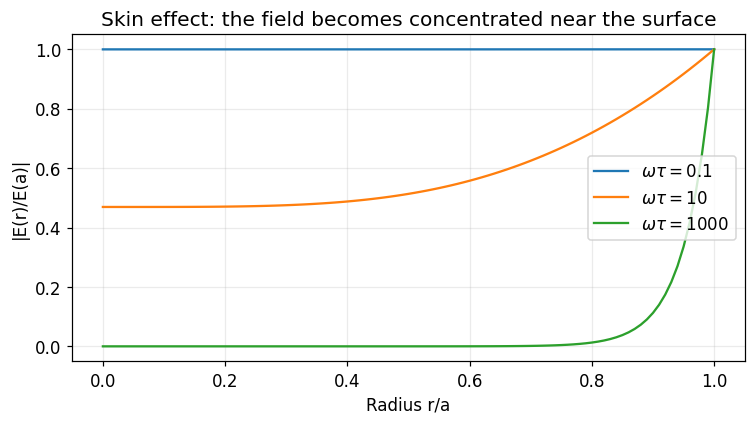

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp
mp.mp.dps = 50
plt.rcParams.update({"figure.dpi":110,"font.size":11})
def F(z):
    if z == 0: return mp.mpf(1)
    k=mp.sqrt(z)
    return k*mp.besseli(0,k)/(2*mp.besseli(1,k))
r=np.linspace(0,1,101)
fig,ax=plt.subplots(figsize=(7,4))
for wt in (0.1,10,1000):
    k=mp.sqrt(1j*wt)
    amp=[float(abs(mp.besseli(0,k*x)/mp.besseli(0,k))) for x in r]
    ax.plot(r,amp,label=rf"$\omega\tau={wt:g}$")
ax.set(xlabel="Radius r/a",ylabel="|E(r)/E(a)|",title="Skin effect: the field becomes concentrated near the surface")
ax.grid(alpha=.25);ax.legend();plt.tight_layout();plt.show()


## 2. はしご型回路は、同心円の層を切り分けたものではない

抵抗を直列に置き、その途中からインダクタンスを並列に分岐させます。各段は空間全体に広がる**場のモード**に対応します。「抵抗1個が導体の薄い輪1枚」とは解釈しません。

ここでは展開点$s_0=0$のType2を使います。
$$Z=R_0+\left[\frac1{sL_1}+\frac1{R_2+\left(1/(sL_3)+\cdots\right)^{-1}}\right]^{-1}.$$
回路は抵抗でエネルギーを散逸し、インダクタンスに磁気エネルギーを蓄えます。FEMで場を繰り返し解く作業を前処理として行い、その後は小さな回路を解く、という役割分担です。[原著の概要](https://www.compumag.org/Proceedings/2017_Daejeon/papers/%5BPA-M1-2%5D_52.pdf)


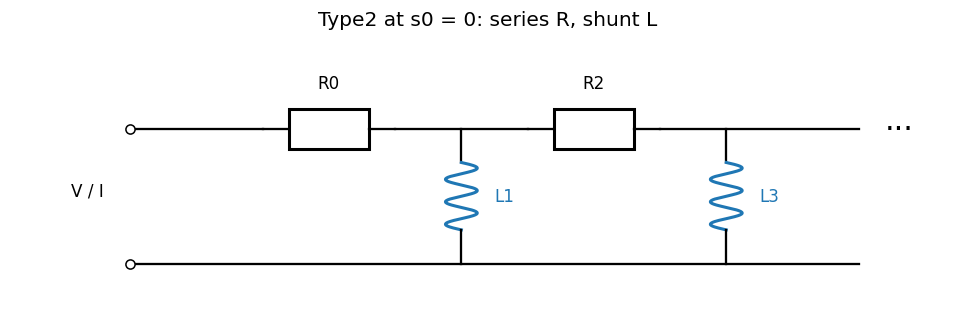

In [2]:
from matplotlib.patches import Rectangle
fig,ax=plt.subplots(figsize=(9,3))
def resistor(x,label):
    ax.plot([x,x+.2],[1,1],color="black")
    ax.add_patch(Rectangle((x+.2,.85),.6,.3,fill=False,lw=2))
    ax.plot([x+.8,x+1],[1,1],color="black")
    ax.text(x+.5,1.3,label,ha="center")
def inductor(x,label):
    ax.plot([x,x],[1,.75],color="black")
    tt=np.linspace(0,6*np.pi,180)
    ax.plot(x+.12*np.sin(tt),.75-.5*tt/(6*np.pi),color="tab:blue",lw=2)
    ax.plot([x,x],[.25,0],color="black")
    ax.text(x+.25,.5,label,va="center",color="tab:blue")
ax.plot([0,1],[1,1],color="black");resistor(1,"R0")
ax.plot([2,3],[1,1],color="black");inductor(2.5,"L1")
resistor(3,"R2");ax.plot([4,5.5],[1,1],color="black");inductor(4.5,"L3")
ax.plot([0,5.5],[0,0],color="black");ax.text(5.7,1,"...",fontsize=20)
ax.text(-.2,.5,"V / I",ha="right");ax.scatter([0,0],[0,1],facecolors="white",edgecolors="black",zorder=5)
ax.set(xlim=(-.9,6.3),ylim=(-.3,1.7),title="Type2 at s0 = 0: series R, shunt L")
ax.axis("off");plt.tight_layout();plt.show()


## 3. 「物理的な回路定数」とは何か

電界・磁界をモードの和で表し、適切に規格化・直交化します。$s_0=0$の基本形では
$$\int\sigma\,\mathbf E_{2n}\!\cdot\!\mathbf E_{2m}\,dV=\delta_{nm}/R_{2n},\qquad
\int\mu\,\mathbf H_{2n+1}\!\cdot\!\mathbf H_{2m+1}\,dV=\delta_{nm}L_{2n+1}.$$
この規格化では電界モードの積分は**Rではなく1/R**です。モードの振幅を変えると積分値も変わるため、規格化を省略して素子値を比較してはいけません。式と場・回路の関係は[原著](https://www.compumag.org/Proceedings/2017_Daejeon/papers/%5BPA-M1-2%5D_52.pdf)を参照してください。

例えば$a=\sigma=\mu=1$の直流丸線では$E_0=1$、単位電流の$H_1=x/(2\pi)$です。したがって$R_0=1/\pi$、$L_1=1/(8\pi)$になります。これは端子特性へのフィッティングではなく、場の積分から求めた値です。

ただし展開点付きType2では偶数段の逆数は$P_j+s_0W_m$、Type1では別の規格化です。そこでのRを、そのまま単一モードのジュール損失と呼ぶのは不正確です。詳細は次のノートで扱います。


In [3]:
R0=1/mp.quad(lambda x:2*mp.pi*x,[0,1])
L1=mp.quad(lambda x:2*mp.pi*x*(x/(2*mp.pi))**2,[0,1])
assert abs(R0-1/mp.pi)<mp.mpf("1e-45")
assert abs(L1-1/(8*mp.pi))<mp.mpf("1e-45")
print("Unit radius/conductivity/permeability:")
print("R0 =",mp.nstr(R0,12),"; L1 =",mp.nstr(L1,12))
# Independent power identity for the exact unit-current AC fields.
for wt in (1,100):
    k=mp.sqrt(1j*wt)
    E=lambda x:k*mp.besseli(0,k*x)/(2*mp.pi*mp.besseli(1,k))
    H=lambda x:mp.besseli(1,k*x)/(2*mp.pi*mp.besseli(1,k))
    P=mp.quad(lambda x:2*mp.pi*x*abs(E(x))**2,[0,1])
    W=mp.quad(lambda x:2*mp.pi*x*abs(H(x))**2,[0,1])
    Z=F(1j*wt)/mp.pi
    error=abs((P+1j*wt*W)/Z-1)
    assert error<mp.mpf("1e-35")
    print(f"omega*tau={wt}: Re(Z)={float(P):.8g}, Im(Z)={float(wt*W):.8g}; power identity error < 1e-35")


Unit radius/conductivity/permeability:
R0 = 0.318309886184 ; L1 = 0.039788735773
omega*tau=1: Re(Z)=0.31996087, Im(Z)=0.039685585; power identity error < 1e-35
omega*tau=100: Re(Z)=1.2091243, Im(Z)=1.1205276; power identity error < 1e-35


ここで交流のE,HはRMSフェーザです。$P=\int\sigma|E|^2$は平均損失、$W=\int\mu|H|^2$は磁界の二次形式で、平均蓄積磁気エネルギーは$W/2$です。端子電流1に対して$Z=P+j\omega W$を数値確認しました。**この交流の複素共役付き積分と、実数展開点でのモード積分を混同しない**ことが大切です。

## 4. 段数を増やすと、どこが良くなるか

丸線の$s_0=0$では、解析的な連分数係数が既知です。
$$R_{2k}=(2k+1)R_{\rm dc},\qquad L_{2k+1}=\frac{R_{\rm dc}\tau}{8(k+1)}.$$
下ではこの係数を使い、打切り後の回路と厳密Bessel解を比較します。これは解析解を使った入門例であり、FEMからモードを生成する実装ではありません。


 1 elements: sampled low-frequency band with error <1% extends to omega*tau=0.07943282347242814
 3 elements: sampled low-frequency band with error <1% extends to omega*tau=5.011872336272725
 7 elements: sampled low-frequency band with error <1% extends to omega*tau=73.56422544596414
15 elements: sampled low-frequency band with error <1% extends to omega*tau=1165.9144011798312


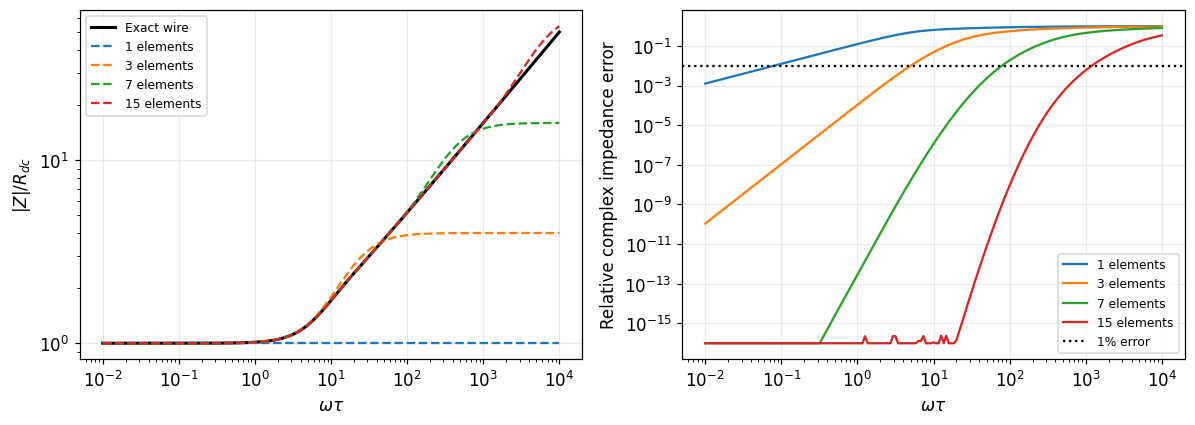

In [4]:
def ladder(coeff,z):
    if z == 0: return coeff[0]
    last=len(coeff)-1
    value=coeff[-1] if last%2==0 else z*coeff[-1]
    for index in range(last-1,-1,-1):
        value=coeff[index]+value if index%2==0 else z*coeff[index]*value/(z*coeff[index]+value)
    return value
wt=np.logspace(-2,4,181)
exact=np.array([complex(F(1j*w)) for w in wt])
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].loglog(wt,abs(exact),"k",lw=2,label="Exact wire")
for count in (1,3,7,15):
    coeff=[float(k+1 if k%2==0 else 1/(4*(k+1))) for k in range(count)]
    model=np.array([ladder(coeff,1j*w) for w in wt])
    err=abs(model/exact-1)
    assert np.isfinite(model).all() and (model.real>0).all()
    axes[0].loglog(wt,abs(model),"--",label=f"{count} elements")
    axes[1].loglog(wt,np.maximum(err,1e-16),label=f"{count} elements")
    first=np.flatnonzero(err>=.01)
    limit=wt[first[0]-1] if len(first) and first[0]>0 else (wt[-1] if not len(first) else None)
    print(f"{count:2d} elements: sampled low-frequency band with error <1% extends to omega*tau={limit}")
axes[1].axhline(.01,color="black",ls=":",label="1% error")
for ax in axes:
    ax.set_xlabel(r"$\omega\tau$");ax.grid(alpha=.25);ax.legend(fontsize=8)
axes[0].set_ylabel(r"$|Z|/R_{dc}$");axes[1].set_ylabel("Relative complex impedance error")
plt.tight_layout();plt.show()


グラフの読み方：左の振幅だけが近くても、位相まで合っているとは限りません。右は複素インピーダンス全体の誤差です。段数を増やすと表現できる帯域が広がりますが、有限段の回路が全周波数で厳密解になるわけではありません。「十分な段数」は対象帯域と許容誤差で決めます。

## 5. CLNと他の縮約、場の定式化の違い

| 名前 | 何を選んでいるか |
|---|---|
| A法・T法 | 同じ物理場を求めるためのポテンシャル・未知量と弱形式 |
| Type1・Type2 | 連分数の形、回路の接続順とモードの規格化 |
| 展開点$s_0$ | どの点の近傍を少ない段数で詳しく表すか |
| 段数 | 保存する場のモードと回路素子の数 |

CLNの特徴は、電界・磁界モードの再帰とエネルギー積分を通じて回路を構成することです。一般の行列縮約にも受動性やエネルギーを保つ手法がありますが、縮約行列を得ることと、各段の場に対応するCauer回路を構成することは同じ作業ではありません。

A法とT法で式の見た目が違っても、復元した場が一致すれば同じTypeの要素値は一致します。今回の丸線検証では既存の境界条件や規格化を修正したのではなく、その対応を導出して確認しました。**同じZだけから内部場の一致を一般に結論してはいけません。**

## 次に読む

- [展開点とエネルギー：何が変わるか](01_expansion_and_energy.ipynb)
- [Type2：A法・T法が同じ回路を与える導出](type2_same_circuit.ipynb)
- [Type1：導出とNGSolve再現](type1_same_circuit.ipynb)

原著：A. Kameari et al., *Cauer Ladder Network Representation of Eddy-Current Fields for Model Order Reduction Using Finite-Element Method*, DOI [10.1109/TMAG.2017.2743224](https://doi.org/10.1109/TMAG.2017.2743224)。上の図は、このノートの解析式から生成したものです。
